<a href="https://colab.research.google.com/github/renuka2929-tech/LP5-Practicals/blob/main/DL1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Import Libraries
import pandas as pd
import numpy as np

from google.colab import files
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
# Upload CSV File
uploaded = files.upload()

Saving HousingData.csv to HousingData.csv


In [5]:
# Load Dataset
data = pd.read_csv("HousingData.csv")

In [6]:
# Display First 5 Rows
print(data.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [7]:
# Remove Missing Values
data = data.dropna()

In [8]:
# Input Features
X = data.drop("MEDV", axis=1)

In [9]:
# Output Target
y = data["MEDV"]

In [10]:
# Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# Create Deep Neural Network Model
model = Sequential()

In [13]:
# Add First Hidden Layer
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Add Second Hidden Layer
model.add(Dense(32, activation='relu'))

In [15]:
# Add Output Layer
model.add(Dense(1))

In [16]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [17]:
# Train Model
model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 1062.9312 - mae: 32.2726
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 1058.1506 - mae: 32.1936
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 1053.5692 - mae: 32.1175
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 1049.1956 - mae: 32.0444
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1044.9513 - mae: 31.9730
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 1040.8181 - mae: 31.9033
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1036.7592 - mae: 31.8348
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 1032.7661 - mae: 31.7674
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 1028.9785 - mae: 31.7035
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 1025.2759 - mae: 31.6407
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 1021.7731 - mae: 31.5819
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1018.3068 - mae: 31.52

In [18]:
# Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Mean Absolute Error:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 113.0456 - mae: 10.6323
Mean Absolute Error: 10.632291793823242


In [19]:
# Predict House Prices
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [21]:
print(predictions)

[[10.967709]]


In [22]:
# Save Model
model.save("boston_house_model.h5")

In [23]:
# Success Message
print("Model Saved Successfully")

Model Saved Successfully


In [24]:
print("\nActual Price vs Predicted Price\n")

for i in range(len(predictions)):
    print("Actual:", y_test.iloc[i], " Predicted:", predictions[i][0])


Actual Price vs Predicted Price

Actual: 21.6  Predicted: 10.967709


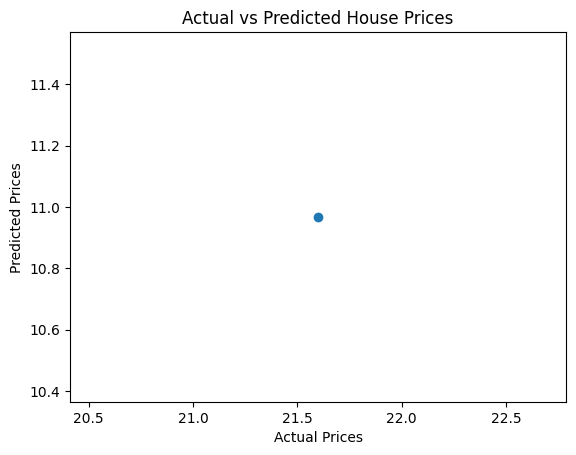

In [26]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()